In [39]:
# import pandas library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Search for best hyperparameters using GridSearchCV and RandomForestRegressor

In [40]:
cars = pd.read_csv("cars.csv")

In [41]:
## create X and Y
y = cars['price']
X = cars.drop(columns=['price'])

In [42]:
X = pd.get_dummies(X)

In [43]:
X.shape

(201, 38)

In [44]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

#### Set aside some data for testing

In [45]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=99)

In [46]:
model = RandomForestRegressor(random_state=99)
params_grid  = [{'n_estimators' : [10,20,30, 50] , 'max_depth' :[2, 3, 4, 8, 10]}]

In [47]:
grid_search = GridSearchCV(model, params_grid, cv = 5)
grid_search.fit(X_train,y_train)

GridSearchCV(cv=5, estimator=RandomForestRegressor(random_state=99),
             param_grid=[{'max_depth': [2, 3, 4, 8, 10],
                          'n_estimators': [10, 20, 30, 50]}])

In [48]:
## display scores 
results = grid_search.cv_results_
for score,param in zip(results['mean_test_score'], results['params']):
      print(score,param)

0.8123974495832448 {'max_depth': 2, 'n_estimators': 10}
0.8342311985966424 {'max_depth': 2, 'n_estimators': 20}
0.8359089719859204 {'max_depth': 2, 'n_estimators': 30}
0.8321844318694602 {'max_depth': 2, 'n_estimators': 50}
0.8414701304004184 {'max_depth': 3, 'n_estimators': 10}
0.8477094061000008 {'max_depth': 3, 'n_estimators': 20}
0.8496080114896071 {'max_depth': 3, 'n_estimators': 30}
0.848558849272702 {'max_depth': 3, 'n_estimators': 50}
0.8512262625989997 {'max_depth': 4, 'n_estimators': 10}
0.8568742333961366 {'max_depth': 4, 'n_estimators': 20}
0.8599682057920859 {'max_depth': 4, 'n_estimators': 30}
0.856404391996732 {'max_depth': 4, 'n_estimators': 50}
0.8530207942771236 {'max_depth': 8, 'n_estimators': 10}
0.8687087280305841 {'max_depth': 8, 'n_estimators': 20}
0.8683890489199019 {'max_depth': 8, 'n_estimators': 30}
0.8681495180226527 {'max_depth': 8, 'n_estimators': 50}
0.8684196540484939 {'max_depth': 10, 'n_estimators': 10}
0.8689179935236824 {'max_depth': 10, 'n_estimator

In [49]:
grid_search.best_params_

{'max_depth': 10, 'n_estimators': 30}

In [50]:
grid_search.best_score_

0.8692328982919818

In [51]:
grid_search.best_estimator_

RandomForestRegressor(max_depth=10, n_estimators=30, random_state=99)

### Build model with best estimator

In [52]:
model = grid_search.best_estimator_

In [53]:
y_pred = model.predict(X_test)

In [54]:
from sklearn.metrics import mean_squared_error, r2_score
mse = mean_squared_error(y_test,y_pred)

In [55]:
r2_score(y_test,y_pred)

0.9351164572183728

In [56]:
np.sqrt(mse)

2391.868132253559

<Axes: xlabel='None', ylabel='price'>

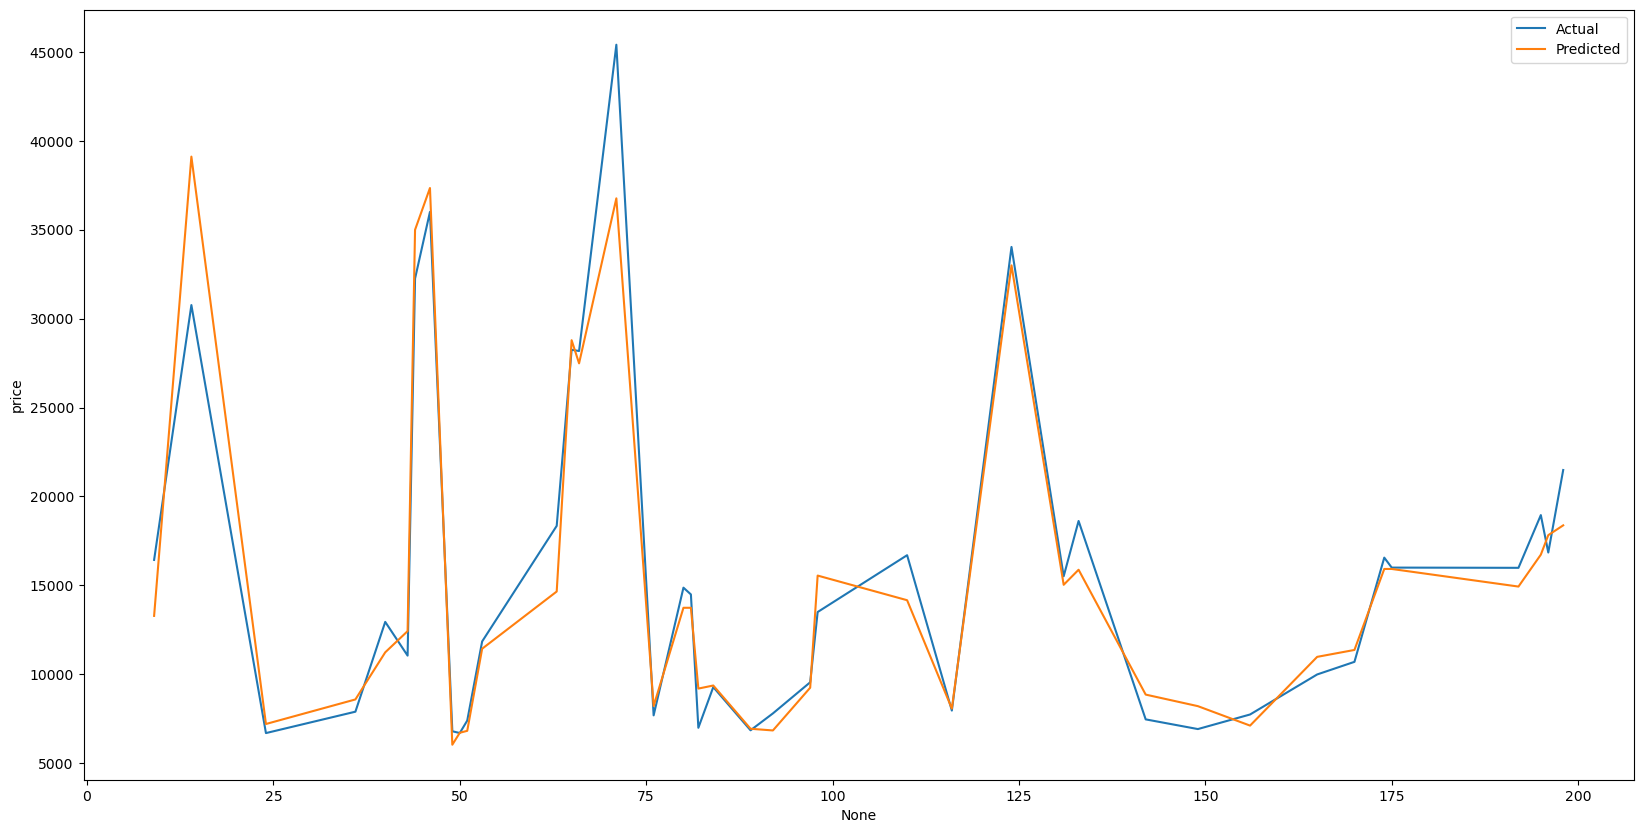

In [57]:
# Compare actual and predicted values
plt.gcf().set_size_inches(20,10)
sns.lineplot( y = y_test, x = X_test.index, label="Actual")
sns.lineplot( y = y_pred, x = X_test.index, label="Predicted")